# М1. Полёт камня

Моделирование броска камня под углом к горизонту. Согласно заданию, рассчитывается траектория движения и исследуется влияние сопротивления воздуха. Мы рассмотрим 3 случая:
1. Идеальный полет (без сопротивления)
2. Вязкое трение (сила сопротивления пропорциональна скорости)
3. Лобовое сопротивление (сила сопротивления пропорциональна квадрату скорости)

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['grid.alpha'] = 0.5

## 1. Параметры броска и константы
Задаем ускорение свободного падения, начальную скорость, угол, массу камня и коэффициенты сопротивления среды.

In [2]:
G_ACCEL = 9.81

V0 = 50.0
ALPHA_DEG = 45.0
ALPHA_RAD = np.radians(ALPHA_DEG)

V0_X = V0 * np.cos(ALPHA_RAD)
V0_Y = V0 * np.sin(ALPHA_RAD)

MASS = 1.0
K_LINEAR = 0.1
K_QUAD = 0.005

## 2. Дифференциальные уравнения движения
Решаем систему уравнений движения для каждого случая с помощью численного интегрирования. Условием остановки расчета является падение камня на землю ($y \le 0$).

In [3]:
def hit_ground(t, Y):
    x, y, vx, vy = Y
    return y

hit_ground.terminal = True
hit_ground.direction = -1

t_span = [0, 100]
y0 = [0, 0, V0_X, V0_Y]

def no_drag_system(t, Y):
    x, y, vx, vy = Y
    return [vx, vy, 0, -G_ACCEL]

sol_no_drag = solve_ivp(
    no_drag_system, t_span, y0,
    events=hit_ground, max_step=0.01
)

def linear_drag_system(t, Y):
    x, y, vx, vy = Y
    ax = -(K_LINEAR / MASS) * vx
    ay = -G_ACCEL - (K_LINEAR / MASS) * vy
    return [vx, vy, ax, ay]

sol_linear = solve_ivp(
    linear_drag_system, t_span, y0,
    events=hit_ground, max_step=0.01
)

def quad_drag_system(t, Y):
    x, y, vx, vy = Y
    v_mag = np.sqrt(vx**2 + vy**2)
    ax = -(K_QUAD / MASS) * v_mag * vx
    ay = -G_ACCEL - (K_QUAD / MASS) * v_mag * vy
    return [vx, vy, ax, ay]

sol_quad = solve_ivp(
    quad_drag_system, t_span, y0,
    events=hit_ground, max_step=0.01
)

## 3. Сравнение с теоретическим расчетом и визуализация
Для движения без трения мы можем рассчитать точную траекторию аналитически и сравнить ее с результатом численного решения.

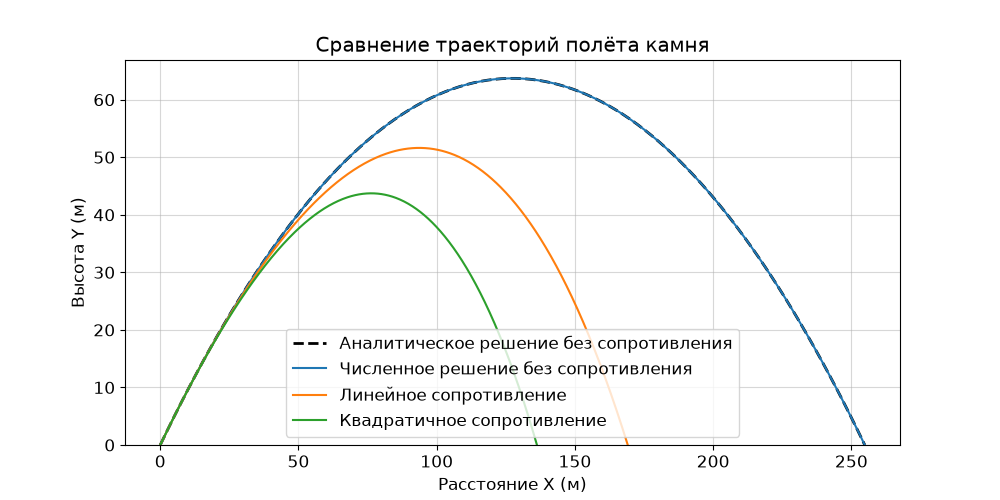

In [4]:
t_theory = np.linspace(0, 2 * V0_Y / G_ACCEL, 100)
x_theory = V0_X * t_theory
y_theory = V0_Y * t_theory - 0.5 * G_ACCEL * t_theory**2

plt.plot(x_theory, y_theory, 'k--', linewidth=2, label='Аналитическое решение без сопротивления')
plt.plot(sol_no_drag.y[0], sol_no_drag.y[1], label='Численное решение без сопротивления')
plt.plot(sol_linear.y[0], sol_linear.y[1], label='Линейное сопротивление')
plt.plot(sol_quad.y[0], sol_quad.y[1], label='Квадратичное сопротивление')

plt.title('Сравнение траекторий полёта камня')
plt.xlabel('Расстояние X (м)')
plt.ylabel('Высота Y (м)')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.show()